## Evaluating predictions on testing data

In [1]:
import os
import sys
import importlib as imp
import numpy as np
import torch
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns

from utils import utils
from data_builder import data_methods
from data_builder import read_landsat
from rasterio.windows import Window

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"pytorch version = {torch.__version__}")

python version = 3.12.0 | packaged by conda-forge | (main, Oct  3 2023, 08:36:57) [Clang 15.0.7 ]
numpy version = 1.26.4
pytorch version = 2.1.2.post3


In [3]:
# GET config
EXP_NAME = "exp_001"
REWRITE = True

config = utils.get_config(EXP_NAME)
config["mode"] = "inference"

directory_paths = utils.get_directories()
SAVE_MODEL_DIR = directory_paths["save_model_dir"]
DATA_DIR = directory_paths["data_dir"]
FIGURES_DIR = directory_paths["figures_dir"]
PREDICTIONS_DIR = directory_paths["predictions_dir"]
LANDSAT_DIR = directory_paths["landsat_dir"]
MOSAICS_DIR = directory_paths["mosaics_dir"]

 --- 2020---
(371, 742) (371, 742)
(165633,) (165633,)


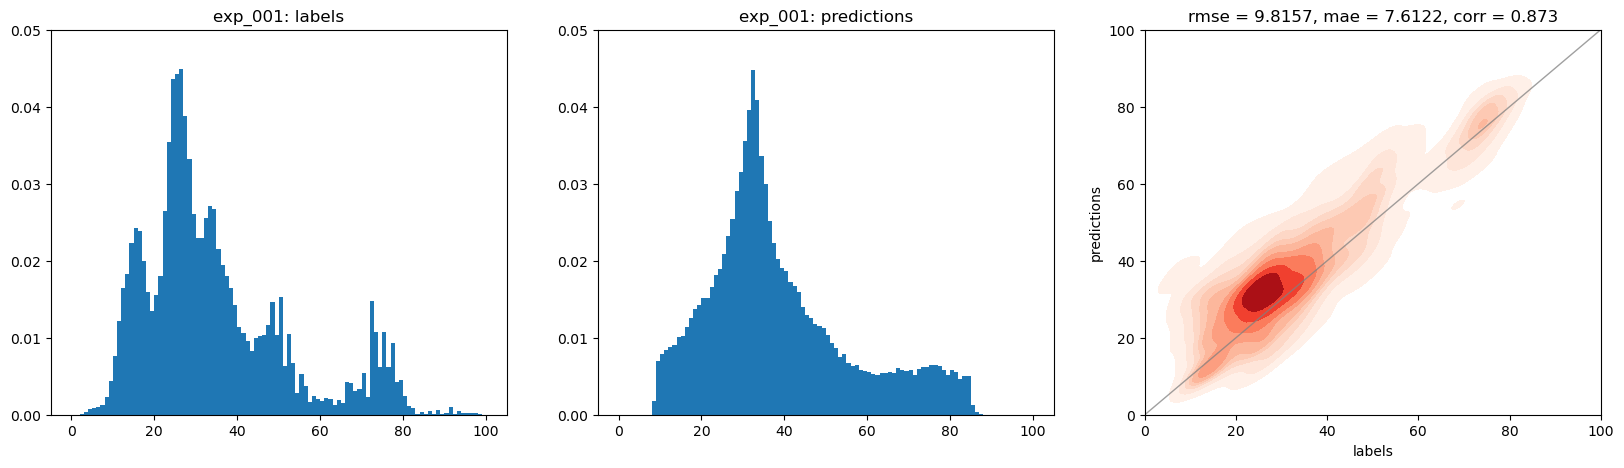

In [4]:
# GET THE DATA
# config["data"]["inference_region"] = (5.0, 8.0, 2.0, 6.0)
config["data"]["inference_region"] = (6.0, 7.0, 3.0, 5.0)

# set and get important config
(lat_s_bound, lat_n_bound, lon_w_bound, lon_e_bound) = read_landsat.get_landsat_bounds(
    config, region=config["data"]["inference_region"]
)

for year in (2020,):
    print(" --- " + str(year) + "---")
    config["inference_years"] = (year,)

    # TILE THE PREDICTIONS TOGETHER
    mosaic_filename = (
        MOSAICS_DIR + config["exp_name"] + "_" + str(config["inference_years"][0]) + "_mlhfi_mosaic.tif"
    )
    labels_filename = DATA_DIR + "hii_" + str(config["inference_years"][0]) + "-01-01_uint8.tif"

    with rasterio.open(mosaic_filename) as predict_tif:
        predictions = np.asarray(predict_tif.read(1), dtype="float")

        with rasterio.open(labels_filename) as label_tif:
            lon_w, lat_n = predict_tif.xy(0, 0, offset="ul")
            lon_e, lat_s = predict_tif.xy(predict_tif.height - 1, predict_tif.width - 1, offset="ul")

            ilat_n, ilon_w = label_tif.index(lon_w, lat_n)
            ilat_s, ilon_e = label_tif.index(lon_e, lat_s)
            # print(lat_s, lat_n, lon_w, lon_e)

            window = Window.from_slices((ilat_n, ilat_s + 1), (ilon_w, ilon_e + 1))
            labels = np.asarray(label_tif.read(1, window=window), dtype="float")

    print(predictions.shape, labels.shape)

    # REMOVE EDGES FOR NOW
    predictions = predictions[7:-7, 7:-7]
    labels = labels[7:-7, 7:-7]

    # FLATTEN AND ANALYZE
    predictions = predictions.flatten()
    labels = labels.flatten()
    predictions, labels = data_methods.remove_nodata(predictions, labels)
    print(labels.shape, predictions.shape)

    # MAKE HISTOGRAMS
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 3, 1)
    bins = np.arange(0, 101, 1)
    plt.hist(labels, bins, density=True)
    plt.title(config["exp_name"] + ": labels")
    plt.ylim(0, 0.05)

    plt.subplot(1, 3, 2)
    bins = np.arange(0, 101, 1)
    plt.hist(predictions, bins, density=True)
    plt.title(config["exp_name"] + ": predictions")
    plt.ylim(0, 0.05)

    # MAKE SUMMARY FIGURE
    rmse = np.sqrt(mean_squared_error(labels, predictions)).round(4)
    mae = mean_absolute_error(labels, predictions).round(4)
    corr = np.corrcoef(labels, predictions)[0, 1].round(4)

    rng = np.random.default_rng(35)
    iplot = rng.choice(np.arange(len(predictions)), size=5_000)

    plt.subplot(1, 3, 3)
    sns.kdeplot(
        x=labels[iplot],
        y=predictions[iplot],
        fill=True,
        cmap="Reds",
        bw_adjust=0.75,
        levels=10,
    )
    plt.plot((0, 100), (0, 100), "-", linewidth=1, color="gray", alpha=0.75)
    plt.title(f"{rmse = }, {mae = }, {corr = }")
    plt.xlabel("labels")
    plt.ylabel("predictions")
    plt.xlim(0, 100)
    plt.ylim(0, 100)

    plt.savefig(
        FIGURES_DIR + config["exp_name"] + "_" + str(year) + "_prediction_metrics.png",
        bbox_inches="tight",
        dpi=300,
    )
    plt.show()
